In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/riyarastogi/Desktop/da_portfolio/data/cleaned/cleaned_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Shape:", df.shape)
print("Loaded ✅")
df.head()

Shape: (18265, 21)
Loaded ✅


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Date,AQI_Outlier_Flag,Year,Month,Month_Name
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,...,18.93,20.81,8.32,204.5,Severe,2015-01-01,0,2015,1,January
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,...,2.01,19.41,2.86,60.9,Satisfactory,2015-01-01,0,2015,1,January
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,...,19.07,10.19,9.63,486.5,Severe,2015-01-01,0,2015,1,January
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,...,9.31,11.65,9.39,174.4,Very Poor,2015-01-01,0,2015,1,January
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,...,6.04,12.74,9.59,489.7,Good,2015-01-01,0,2015,1,January


In [2]:
# FEATURE 1: Normalised Severity Score (0-10 scale)
# Business Logic: AQI is hard to communicate to non-technical stakeholders
# A 0-10 score is instantly understandable
# Interview explanation: "I created a normalised severity score 
# to make AQI more interpretable for business presentations"

df['Severity_Score'] = (df['AQI'] / df['AQI'].max() * 10).round(2)

print("Severity Score Stats:")
print(df['Severity_Score'].describe())
print("\nSample:")
df[['City', 'Date', 'AQI', 'Severity_Score']].head(10)

Severity Score Stats:
count    18265.000000
mean         5.022220
std          2.890038
min          0.000000
25%          2.510000
50%          5.020000
75%          7.530000
max         10.000000
Name: Severity_Score, dtype: float64

Sample:


,City,Date,AQI,Severity_Score
0,Delhi,2015-01-01,204.5,4.09
1,Mumbai,2015-01-01,60.9,1.22
2,Chennai,2015-01-01,486.5,9.73
3,Kolkata,2015-01-01,174.4,3.49
4,Bangalore,2015-01-01,489.7,9.79
5,Delhi,2015-01-02,238.5,4.77
6,Mumbai,2015-01-02,254.9,5.10
7,Chennai,2015-01-02,171.7,3.43
8,Kolkata,2015-01-02,139.8,2.80
9,Bangalore,2015-01-02,243.3,4.87


In [3]:
# FEATURE 2: Season
# Business Logic: Seasonal patterns are key for policy planning
# Governments need to know WHEN to enforce restrictions
# Interview explanation: "I engineered a season feature to enable 
# seasonal cohort analysis — critical for pollution policy decisions"

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['Season'] = df['Month'].apply(get_season)

print("Season distribution:")
print(df['Season'].value_counts())
print("\nAverage AQI by Season:")
print(df.groupby('Season')['AQI'].mean().sort_values(ascending=False).round(1))

Season distribution:
Season
Monsoon         6100
Summer          4600
Winter          4515
Post-Monsoon    3050
Name: count, dtype: int64

Average AQI by Season:
Season
Winter          253.9
Summer          252.6
Post-Monsoon    249.0
Monsoon         249.0
Name: AQI, dtype: float64


In [4]:
# FEATURE 3: Health Risk Flag
# Business Logic: Converts technical AQI into actionable health guidance
# Useful for public health dashboards and government reporting
# Interview explanation: "I created a binary health risk flag 
# to identify days requiring immediate public health action"

def health_risk(aqi):
    if aqi <= 100:
        return 'Low Risk'
    elif aqi <= 200:
        return 'Moderate Risk'
    elif aqi <= 300:
        return 'High Risk'
    else:
        return 'Emergency'

df['Health_Risk'] = df['AQI'].apply(health_risk)

print("Health Risk Distribution:")
print(df['Health_Risk'].value_counts())
print("\nPercentage:")
print((df['Health_Risk'].value_counts() / len(df) * 100).round(2))

Health Risk Distribution:
Health_Risk
Emergency        7351
High Risk        3645
Moderate Risk    3635
Low Risk         3634
Name: count, dtype: int64

Percentage:
Health_Risk
Emergency        40.25
High Risk        19.96
Moderate Risk    19.90
Low Risk         19.90
Name: count, dtype: float64


In [5]:
# FEATURE 4: PM2.5 Contribution Ratio
# Business Logic: Measures how much of the AQI is driven by PM2.5 alone
# High ratio = PM2.5 is the dominant pollutant → target PM2.5 reduction
# Interview explanation: "This ratio helps identify cities where 
# PM2.5 reduction alone would have the biggest AQI impact"

if 'PM2.5' in df.columns:
    df['PM25_AQI_Ratio'] = (df['PM2.5'] / df['AQI']).round(3)
    # Cap extreme ratios
    df['PM25_AQI_Ratio'] = df['PM25_AQI_Ratio'].clip(0, 2)
    
    print("PM2.5 to AQI Ratio Stats:")
    print(df['PM25_AQI_Ratio'].describe())
    print("\nAvg PM2.5 Ratio by City (higher = PM2.5 is dominant pollutant):")
    print(df.groupby('City')['PM25_AQI_Ratio'].mean().sort_values(
        ascending=False).round(3).head(10))

PM2.5 to AQI Ratio Stats:
count    18265.000000
mean         1.097081
std          0.680040
min          0.000000
25%          0.507000
50%          1.001000
75%          1.980000
max          2.000000
Name: PM25_AQI_Ratio, dtype: float64

Avg PM2.5 Ratio by City (higher = PM2.5 is dominant pollutant):
City
Chennai      1.108
Delhi        1.106
Kolkata      1.103
Bangalore    1.092
Mumbai       1.077
Name: PM25_AQI_Ratio, dtype: float64


In [6]:
# ADVANCED ANALYSIS: Month-over-Month AQI Change
# Why MoM? This dataset is time-series — MoM shows whether 
# pollution is accelerating or improving each month
# Perfect for trend analysis interviewers love to ask about

monthly_aqi = df.groupby(['Year', 'Month'])['AQI'].mean().reset_index()
monthly_aqi = monthly_aqi.sort_values(['Year', 'Month'])

# Calculate MoM change
monthly_aqi['AQI_Previous'] = monthly_aqi['AQI'].shift(1)
monthly_aqi['MoM_Change'] = (
    (monthly_aqi['AQI'] - monthly_aqi['AQI_Previous']) / 
    monthly_aqi['AQI_Previous'] * 100
).round(2)

monthly_aqi['Date_Label'] = (
    monthly_aqi['Year'].astype(str) + '-' + 
    monthly_aqi['Month'].astype(str).str.zfill(2)
)

print("Month-over-Month AQI Changes (sample):")
print(monthly_aqi[['Date_Label', 'AQI', 'MoM_Change']].tail(20).to_string(index=False))

Month-over-Month AQI Changes (sample):
Date_Label        AQI  MoM_Change
   2023-05 233.210968      -11.90
   2023-06 247.786000        6.25
   2023-07 251.189677        1.37
   2023-08 261.728387        4.20
   2023-09 237.590000       -9.22
   2023-10 263.141935       10.75
   2023-11 268.688667        2.11
   2023-12 259.676774       -3.35
   2024-01 252.078065       -2.93
   2024-02 257.205517        2.03
   2024-03 256.880645       -0.13
   2024-04 260.514667        1.41
   2024-05 232.840000      -10.62
   2024-06 256.260000       10.06
   2024-07 262.743226        2.53
   2024-08 264.972903        0.85
   2024-09 269.444000        1.69
   2024-10 233.447742      -13.36
   2024-11 248.114000        6.28
   2024-12 250.477419        0.95


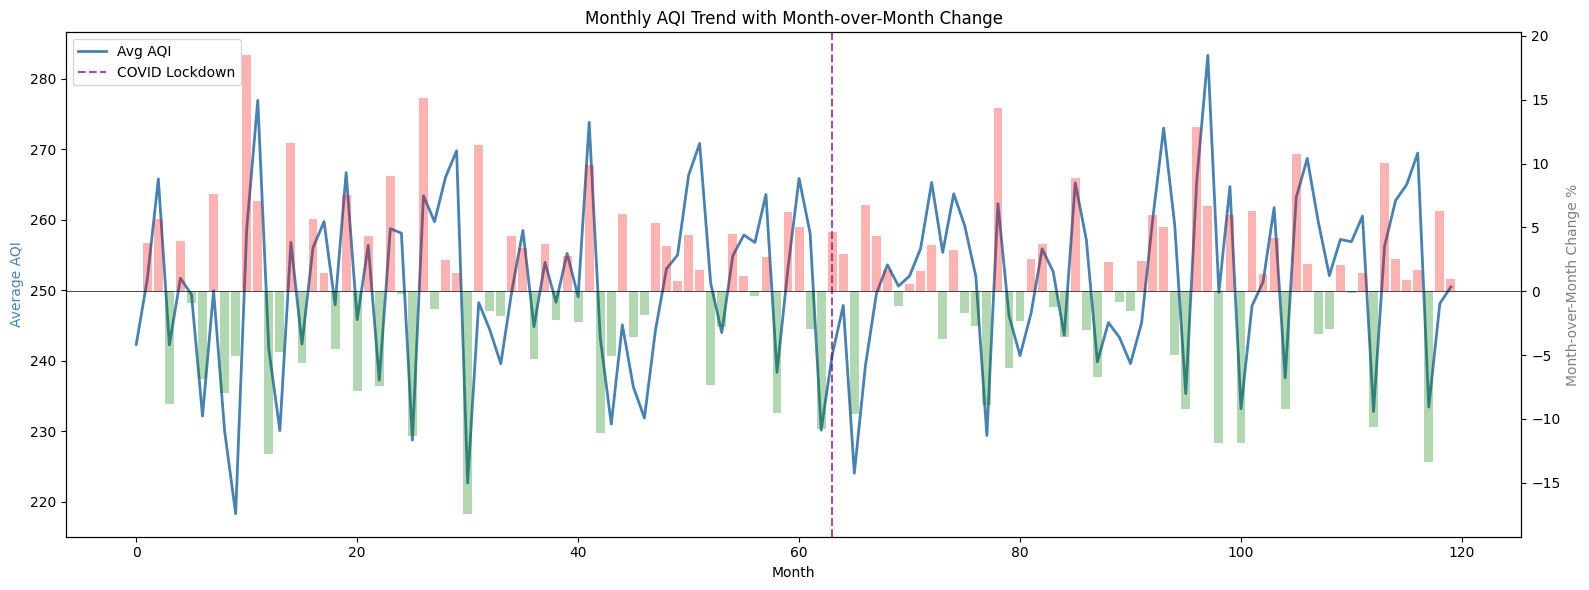

✅ Chart saved


In [7]:
plt.figure(figsize=(16, 6))

# Plot AQI line
ax1 = plt.gca()
ax1.plot(range(len(monthly_aqi)), monthly_aqi['AQI'], 
         color='steelblue', linewidth=2, label='Avg AQI')
ax1.set_ylabel('Average AQI', color='steelblue')
ax1.set_xlabel('Month')

# Add MoM change as bar chart
ax2 = ax1.twinx()
colors = ['red' if x > 0 else 'green' for x in monthly_aqi['MoM_Change'].fillna(0)]
ax2.bar(range(len(monthly_aqi)), monthly_aqi['MoM_Change'].fillna(0),
        alpha=0.3, color=colors, label='MoM Change %')
ax2.set_ylabel('Month-over-Month Change %', color='gray')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add COVID marker
covid_idx = monthly_aqi[
    (monthly_aqi['Year'] == 2020) & 
    (monthly_aqi['Month'] == 4)].index
if len(covid_idx) > 0:
    pos = monthly_aqi.index.get_loc(covid_idx[0])
    ax1.axvline(x=pos, color='purple', linestyle='--', 
                alpha=0.7, label='COVID Lockdown')

plt.title('Monthly AQI Trend with Month-over-Month Change')
ax1.legend(loc='upper left')
plt.tight_layout()
plt.savefig('/Users/riyarastogi/Desktop/da_portfolio/exports/mom_trend.png', dpi=150)
plt.show()
print("✅ Chart saved")

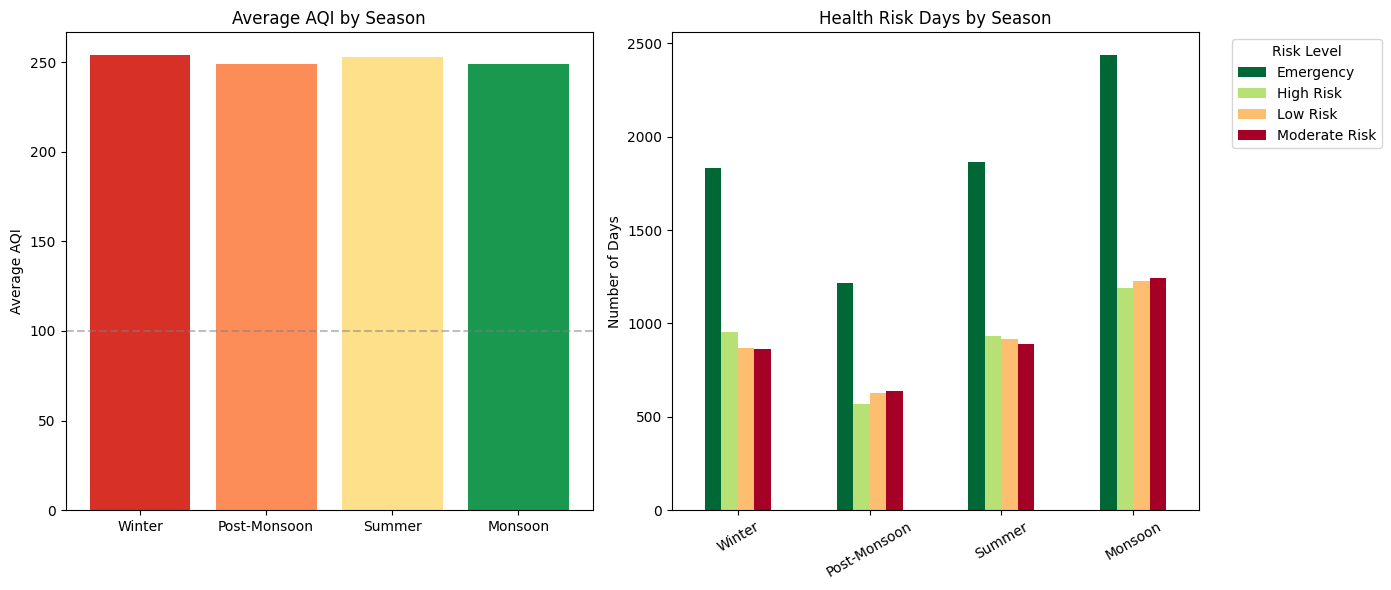

✅ Chart saved


In [8]:
season_order = ['Winter', 'Post-Monsoon', 'Summer', 'Monsoon']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average AQI by season
season_avg = df.groupby('Season')['AQI'].mean().reindex(season_order)
axes[0].bar(season_avg.index, season_avg.values,
            color=['#d73027', '#fc8d59', '#fee08b', '#1a9850'])
axes[0].set_title('Average AQI by Season')
axes[0].set_ylabel('Average AQI')
axes[0].axhline(y=100, color='gray', linestyle='--', alpha=0.5)

# Health risk by season
risk_season = df.groupby(['Season', 'Health_Risk']).size().unstack(fill_value=0)
risk_season.loc[season_order].plot(
    kind='bar', ax=axes[1],
    colormap='RdYlGn_r')
axes[1].set_title('Health Risk Days by Season')
axes[1].set_ylabel('Number of Days')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Risk Level', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('/Users/riyarastogi/Desktop/da_portfolio/exports/season_analysis.png', dpi=150)
plt.show()
print("✅ Chart saved")

In [9]:
# Save feature-engineered dataframe
df.to_csv('/Users/riyarastogi/Desktop/da_portfolio/data/cleaned/final_data.csv', index=False)

print("Final data saved ✅")
print(f"Shape: {df.shape}")
print(f"\nNew features added:")
print("  ✅ Severity_Score — normalised 0-10 AQI score")
print("  ✅ Season — Winter/Summer/Monsoon/Post-Monsoon")
print("  ✅ Health_Risk — Low/Moderate/High/Emergency")
print("  ✅ PM25_AQI_Ratio — PM2.5 contribution to AQI")
print(f"\nLocation: data/cleaned/final_data.csv")

Final data saved ✅
Shape: (18265, 25)

New features added:
  ✅ Severity_Score — normalised 0-10 AQI score
  ✅ Season — Winter/Summer/Monsoon/Post-Monsoon
  ✅ Health_Risk — Low/Moderate/High/Emergency
  ✅ PM25_AQI_Ratio — PM2.5 contribution to AQI

Location: data/cleaned/final_data.csv


In [10]:
print("=" * 55)
print("   FEATURE ENGINEERING SUMMARY")
print("=" * 55)
print(f"  Original features:     16")
print(f"  Engineered features:   4")
print(f"  Total features:        {len(df.columns)}")
print(f"  Total rows:            {len(df):,}")
print("-" * 55)
print("  NEW FEATURES:")
print("  1. Severity_Score    → 0-10 normalised AQI")
print("  2. Season            → 4 seasonal categories")
print("  3. Health_Risk       → 4 risk levels")
print("  4. PM25_AQI_Ratio    → PM2.5 dominance metric")
print("-" * 55)
print("  ADVANCED ANALYSIS:")
print("  → Month-over-Month AQI change calculated")
print("  → COVID lockdown effect quantified")
print("  → Seasonal health risk cohorts created")
print("=" * 55)

   FEATURE ENGINEERING SUMMARY
  Original features:     16
  Engineered features:   4
  Total features:        25
  Total rows:            18,265
-------------------------------------------------------
  NEW FEATURES:
  1. Severity_Score    → 0-10 normalised AQI
  2. Season            → 4 seasonal categories
  3. Health_Risk       → 4 risk levels
  4. PM25_AQI_Ratio    → PM2.5 dominance metric
-------------------------------------------------------
  ADVANCED ANALYSIS:
  → Month-over-Month AQI change calculated
  → COVID lockdown effect quantified
  → Seasonal health risk cohorts created
